# P13: The Aesthetics of Generation
## Stylometric Analysis of Qwen Language Models
This notebook demonstrates the stylometric analysis pipeline,
comparing writing styles across three Qwen model variants.
- **qwen** (Qwen2.5-7B-Instruct) — small model
- **qwen72** (Qwen2.5-72B-Instruct) — large model  
- **qwen3** (Qwen3-8B) — newest generation

In [1]:
import sys
sys.path.append("../src")

from visualizer import load_features, plot_all_features, plot_pca, plot_tsne
from evaluator import load_features, train_and_evaluate, plot_confusion_matrix, plot_feature_importance
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

print("✅ Libraries loaded!")

✅ Libraries loaded!


## 1. Dataset Overview
36 texts collected: 3 models × 4 genres × 3 repeats

In [2]:
df = load_features("../data/features.csv")
print(f"Total texts: {len(df)}")
print(f"Models: {list(df['model'].unique())}")
print(f"Genres: {list(df['genre'].unique())}")
print(f"Features:         {len(df.columns) - 2}")
print()
print("📊 Average per model:")
df.groupby("model")[["lexical_diversity","avg_sentence_length","adj_ratio","verb_ratio", "noun_ratio",
                     "punct_frequency", "syntactic_depth","sentiment_polarity", "readability"]
                     ].mean().round(3)

Total texts: 36
Models: ['qwen', 'qwen72', 'qwen3']
Genres: ['narration', 'argumentation', 'dialogue', 'description']
Features:         9

📊 Average per model:


,lexical_diversity,avg_sentence_length,adj_ratio,verb_ratio,noun_ratio,punct_frequency,syntactic_depth,sentiment_polarity,readability
model,,,,,,,,,
qwen,0.704,16.064,0.105,0.126,0.273,0.222,0.086,0.178,57.631
qwen3,0.710,15.538,0.092,0.146,0.309,0.285,0.075,0.118,58.465
qwen72,0.664,18.332,0.092,0.134,0.254,0.188,0.093,0.193,58.513


## 2. Stylometric Features Analysis
All 9 features visualized in a single figure.
Error bars show standard deviation across 3 repeats.

> **Note:** Error bars represent the standard deviation across 3 repeated 
> runs of the same prompt. Short bars = consistent style across runs. 
> Long bars = more variable output.

✅ Saved: results/all_features.png


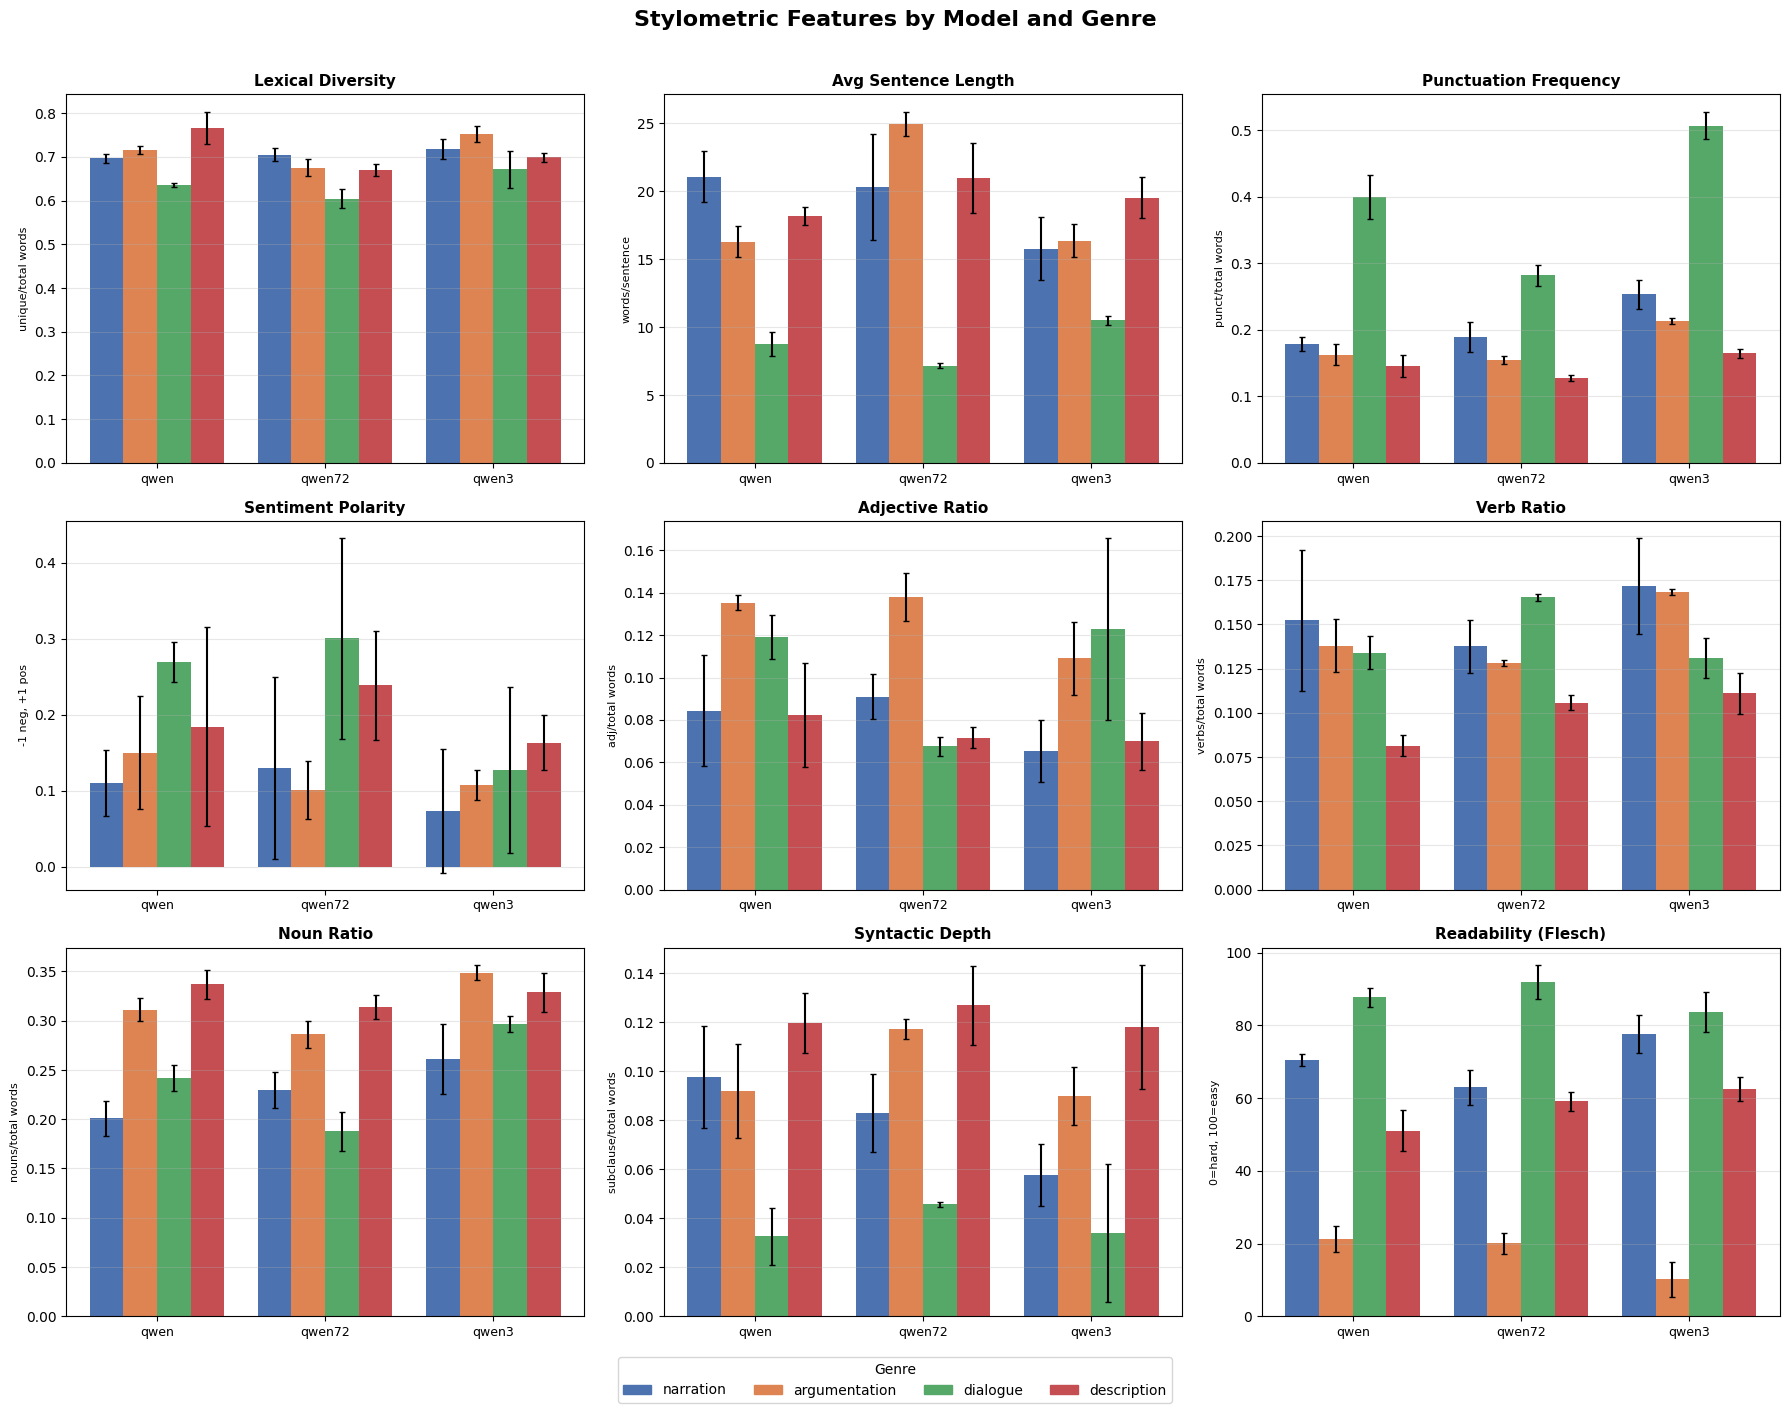

In [4]:
plot_all_features(df)
plt.show()

## 3. PCA (Principal Component Analysis) — Stylistic Distance Between Models
Reducing all 9 features into 2D to visualize how far apart the models are in "style space".
If models cluster separately = distinct styles!

✅ Saved: results/pca_styles.png


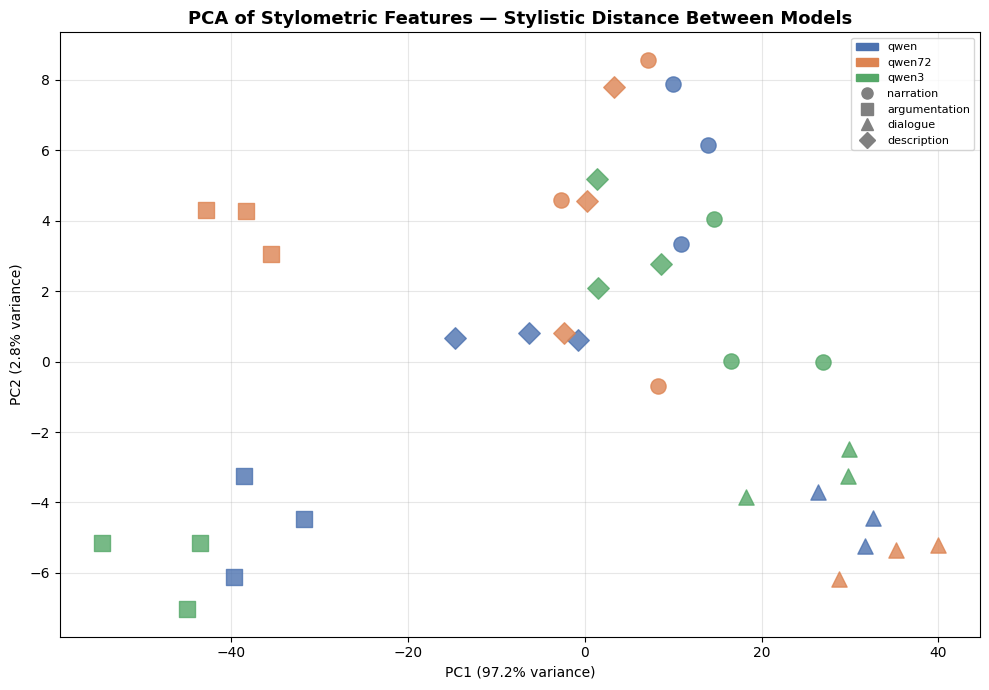

In [5]:
plot_pca(df)
plt.show()

## 4. t-SNE — Aesthetic Landscape
t-SNE preserves local structure better than PCA,
revealing clearer genre and model clusters.

✅ Saved: results/tsne_styles.png


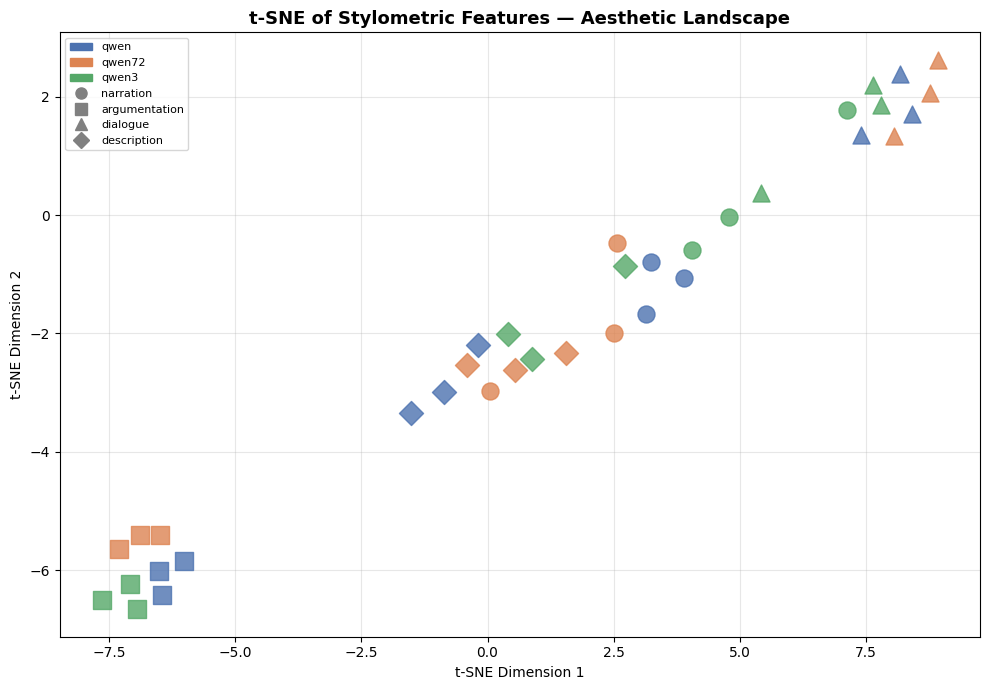

In [6]:
plot_tsne(df)
plt.show()

## 5. Classifier — Can We Identify Which Model Wrote a Text?
Training a Random Forest classifier on stylometric features.
Accuracy above 33.3% (chance level) = models have distinct styles!

In [8]:
from sklearn.preprocessing import LabelEncoder
clf, le, scores = train_and_evaluate(df)

COMPARATIVE EVALUATION RESULTS
Dataset size:     36 texts
Number of models: 3
Features used:    9

Accuracy (Leave-One-Out): 63.9%
Chance level:             33.3%

✅ RESULT: Classifier performs ABOVE chance level!
   → Models have measurable stylistic differences.


### Confusion Matrix (Leave-One-Out Cross-Validation)

✅ Saved: results/confusion_matrix.png


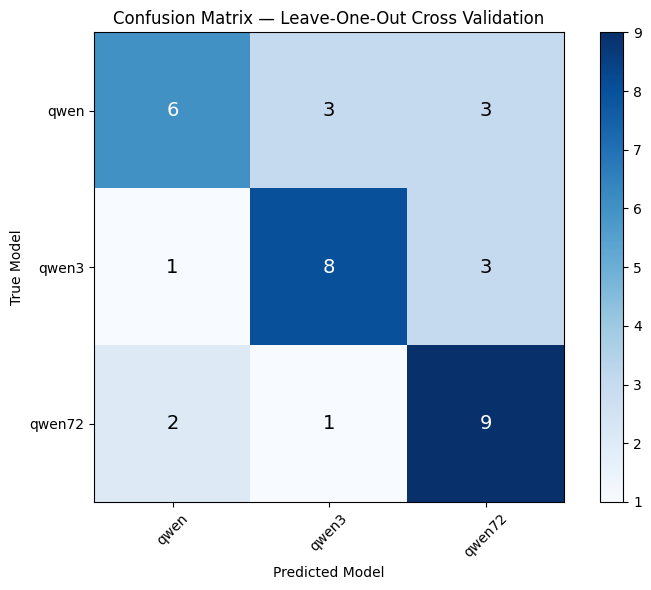

In [9]:
plot_confusion_matrix(clf, df, le)
plt.show()

### Feature Importance
Which stylometric features best distinguish the models?

✅ Saved: results/feature_importance.png


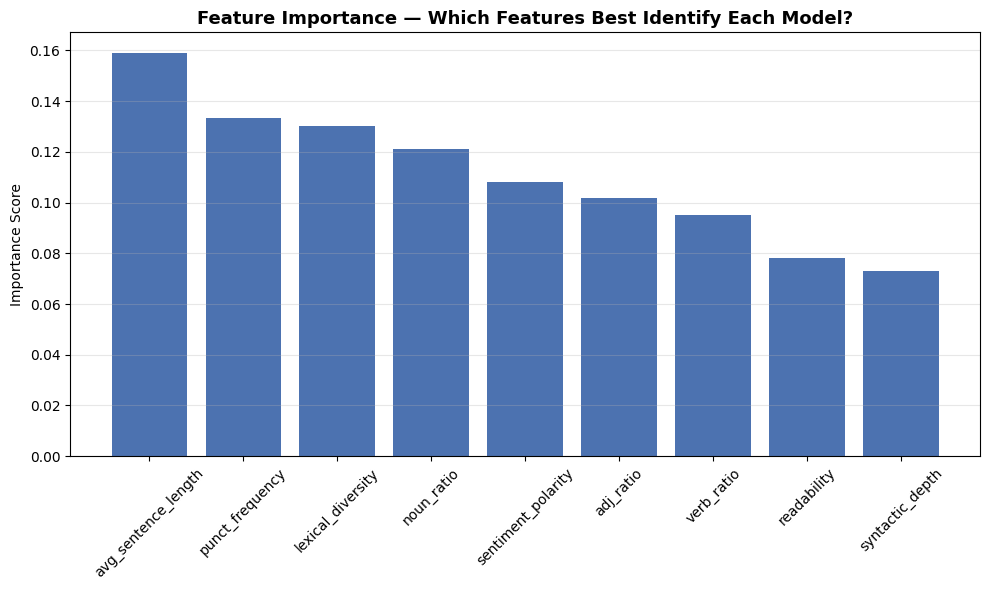

In [10]:
plot_feature_importance(clf, df, le)
plt.show()

## 6. Style Transfer (Optional Experiment)

**Research question:** Can Qwen2.5-7B emulate Qwen2.5-72B's stylistic 
fingerprint when given explicit style instructions?

**Pipeline:**
- Take 1 text per genre from `qwen` (Qwen2.5-7B)
- Ask `qwen` to rewrite it in `qwen72`'s formal academic style
- Repeat 3 times and average results for reliability
- Measure whether features shift toward `qwen72`'s profile

✅ = feature moved **closer** to qwen72 target  
❌ = feature moved **away** from qwen72 target

In [7]:
import json

with open("../data/style_transfer.json", "r") as f:
    transfer_results = json.load(f)

total_success = 0
total_features = 0

for r in transfer_results:
    print(f"\n📝 Genre: {r['genre'].upper()} ({r['n_runs']} runs averaged)")
    print(f"{'Feature':<25} {'qwen':>10} {'qwen rewrite':>14} {'qwen72 target':>14}")
    print("-" * 65)

    genre_success = 0
    for feature in r["original"]:
        orig   = r["original"][feature]
        trans  = r["transferred"][feature]
        target = r["qwen72_avg"][feature]
        arrow  = "✅" if abs(trans - target) < abs(orig - target) else "❌"
        if abs(trans - target) < abs(orig - target):
            genre_success += 1
        total_features += 1
        print(f"{feature:<25} {orig:>10} {trans:>14} {target:>14} {arrow}")

    total_success += genre_success
    print(f"  → {genre_success}/9 features shifted toward qwen72 style")

print(f"\n📊 Overall: {total_success}/{total_features} features "
      f"({total_success/total_features*100:.1f}%) shifted toward qwen72")
print(f"(averaged over 3 runs per genre)")


📝 Genre: NARRATION (3 runs averaged)
Feature                         qwen   qwen rewrite  qwen72 target
-----------------------------------------------------------------
lexical_diversity              0.698          0.695          0.705 ❌
avg_sentence_length           18.714         22.857         20.278 ❌
adj_ratio                      0.061          0.085          0.091 ✅
verb_ratio                      0.16          0.138          0.138 ✅
noun_ratio                     0.176          0.231           0.23 ✅
punct_frequency                0.191          0.155          0.189 ❌
syntactic_depth                0.122          0.123          0.083 ❌
sentiment_polarity             0.168          0.058           0.13 ❌
readability                   69.354          34.92         62.937 ❌
  → 3/9 features shifted toward qwen72 style

📝 Genre: ARGUMENTATION (3 runs averaged)
Feature                         qwen   qwen rewrite  qwen72 target
------------------------------------------------------

### Style Transfer — Key Findings

| Genre | Features Shifted | Success Rate |
|---|---|---|
| Narration | 3/9 | 33% |
| Argumentation | 6/9 | 67% |
| Dialogue | 3/9 | 33% |
| Description | 4/9 | 44% |
| **Overall** | **16/36** | **44.4%** |

**Most transferable features:** verb ratio, noun ratio, avg sentence length  
**Most resistant features:** readability, punctuation frequency, sentiment polarity

> **Finding:** Style transfer partially succeeded — syntactic features 
> (verb/noun ratios) were more malleable than surface features 
> (readability, punctuation), suggesting deep syntactic style is easier 
> to emulate than surface-level stylistic markers.

## 7. Conclusions

### Key Findings:
1. **Genre effect dominates:** Genre has a stronger effect on stylometric
   features than model identity, as shown by PCA and t-SNE clustering.

2. **qwen72 is most distinctive:** Longest sentences (18.33 words),
   least punctuation (0.188) → most formal, academic style.

3. **qwen3 is most expressive:** Most punctuation (0.285), shortest
   sentences (15.54 words) → dramatic, expressive style.

4. **qwen is most balanced:** Positioned between the other two models
   on most features, with the exception of readability, where it scores slightly lower than both.

5. **Classifier: 63.9% accuracy** — nearly double the 33.3% chance
   baseline, confirming models have measurable stylistic differences.

6. **Generation > Size:** Qwen3-8B and Qwen2.5-72B are rarely confused,
   suggesting model generation is a stronger stylistic differentiator
   than model size.

> **Answer to research question: Yes — Qwen model variants exhibit
> measurably distinct stylometric fingerprints.**